# Forecast GBDT Benchmark

Notebook sinh dữ liệu doanh số mô phỏng, tạo feature time-series, rồi benchmark **XGBoost**, **LightGBM** và **CatBoost** với **Seasonal Naive** baseline. Model thắng được chọn theo MAE trung bình của rolling-origin backtest.

> Lưu ý: synthetic data chứng minh pipeline kỹ thuật, không phải kết luận model tốt nhất cho dữ liệu thật.

In [1]:
%pip install -q numpy pandas matplotlib scikit-learn lightgbm xgboost catboost msvc-runtime

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

from pathlib import Path
from time import perf_counter
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

RANDOM_SEED = 20260918
HORIZON_DAYS = 7
N_BACKTEST_FOLDS = 3
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'forecast' / 'sales_daily_synthetic.csv'
TARGET_COLUMNS = ['date', 'store_id', 'sku', 'category', 'qty', 'promotion_flag']
NUMERIC_FEATURES = ['lag_1', 'lag_7', 'lag_14', 'roll_mean_7', 'roll_std_7', 'weekday', 'is_weekend', 'is_holiday', 'promotion_flag']
CATEGORICAL_FEATURES = ['store_id', 'sku', 'category']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
np.random.seed(RANDOM_SEED)
assert DATA_PATH.exists(), f'Không tìm thấy {DATA_PATH}. Chạy script build assets hoặc sửa DATA_PATH.'
print(f'Data: {DATA_PATH}')

Data: C:\phule\doantotnghiep\data\forecast\sales_daily_synthetic.csv


## 1. Đọc và kiểm tra dữ liệu

Mỗi dòng là doanh số của một SKU tại một cửa hàng trong một ngày.

In [3]:
sales = pd.read_csv(DATA_PATH, parse_dates=['date'])
sales = sales.sort_values(['store_id', 'sku', 'date']).reset_index(drop=True)
assert list(sales.columns) == TARGET_COLUMNS
assert not sales.isna().any().any(), 'Dữ liệu có giá trị thiếu.'
expected_rows = sales.groupby(['store_id', 'sku'])['date'].size()
assert expected_rows.nunique() == 1, 'Mỗi chuỗi store/SKU phải có cùng số ngày.'
print(f'Số dòng: {len(sales):,}')
print(f'Cửa hàng: {sales.store_id.nunique()} | SKU: {sales.sku.nunique()} | Ngày/chuỗi: {expected_rows.iloc[0]}')
display(sales.head())

Số dòng: 5,040
Cửa hàng: 3 | SKU: 8 | Ngày/chuỗi: 210


,date,store_id,sku,category,qty,promotion_flag
0,2026-03-01,STORE_01,BANH_ORION,SNACK,18,0
1,2026-03-02,STORE_01,BANH_ORION,SNACK,15,0
2,2026-03-03,STORE_01,BANH_ORION,SNACK,16,1
3,2026-03-04,STORE_01,BANH_ORION,SNACK,20,1
4,2026-03-05,STORE_01,BANH_ORION,SNACK,14,0


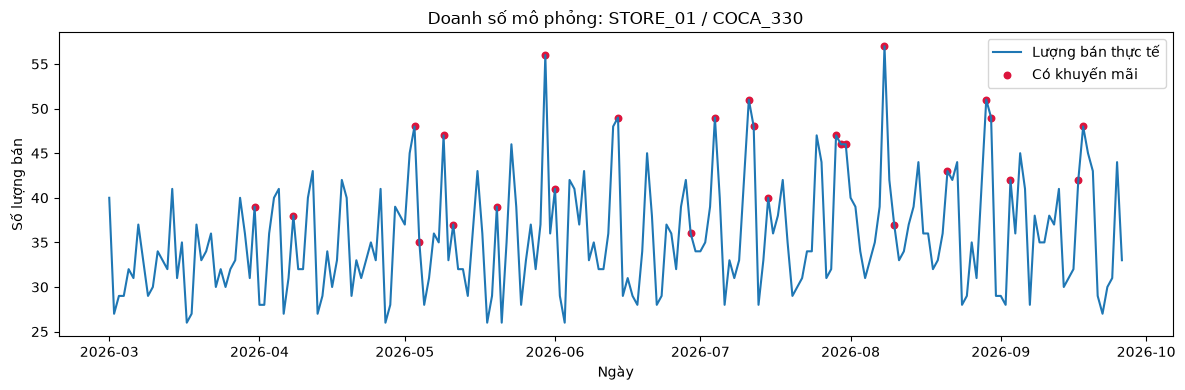

In [4]:
example = sales.query("store_id == 'STORE_01' and sku == 'COCA_330'")
plt.figure(figsize=(12, 4))
plt.plot(example['date'], example['qty'], label='Lượng bán thực tế')
plt.scatter(example.loc[example['promotion_flag'].eq(1), 'date'], example.loc[example['promotion_flag'].eq(1), 'qty'], color='crimson', s=22, label='Có khuyến mãi')
plt.title('Doanh số mô phỏng: STORE_01 / COCA_330')
plt.xlabel('Ngày')
plt.ylabel('Số lượng bán')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Feature engineering

Lag và rolling statistics đều `shift(1)` trước khi tính. Điều này bảo đảm feature tại ngày *t* chỉ thấy doanh số đến ngày *t-1*, không gây target leakage.

In [5]:
def add_calendar_columns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result['weekday'] = result['date'].dt.weekday
    result['is_weekend'] = (result['weekday'] >= 5).astype(int)
    result['is_holiday'] = ((result['date'].dt.month == 4) & result['date'].dt.day.isin([29, 30])).astype(int)
    return result

def build_training_features(history: pd.DataFrame) -> pd.DataFrame:
    result = add_calendar_columns(history)
    group = result.groupby(['store_id', 'sku'], group_keys=False)['qty']
    result['lag_1'] = group.shift(1)
    result['lag_7'] = group.shift(7)
    result['lag_14'] = group.shift(14)
    shifted = group.shift(1)
    result['roll_mean_7'] = shifted.groupby([result['store_id'], result['sku']]).transform(lambda values: values.rolling(7, min_periods=7).mean())
    result['roll_std_7'] = shifted.groupby([result['store_id'], result['sku']]).transform(lambda values: values.rolling(7, min_periods=7).std())
    return result.dropna(subset=NUMERIC_FEATURES).reset_index(drop=True)

features = build_training_features(sales)
assert not features[NUMERIC_FEATURES].isna().any().any()
display(features.head())

,date,store_id,sku,category,qty,promotion_flag,weekday,is_weekend,is_holiday,lag_1,lag_7,lag_14,roll_mean_7,roll_std_7
0,2026-03-15,STORE_01,BANH_ORION,SNACK,19,0,6,1,0,17.0,17.0,18.0,14.857143,1.864454
1,2026-03-16,STORE_01,BANH_ORION,SNACK,17,0,0,0,0,19.0,14.0,15.0,15.142857,2.340126
2,2026-03-17,STORE_01,BANH_ORION,SNACK,13,0,1,0,0,17.0,12.0,16.0,15.571429,2.370453
3,2026-03-18,STORE_01,BANH_ORION,SNACK,15,0,2,0,0,13.0,14.0,20.0,15.714286,2.138090
4,2026-03-19,STORE_01,BANH_ORION,SNACK,18,0,3,0,0,15.0,14.0,14.0,15.857143,2.035401


## 3. Model helpers và recursive forecast

Backtest dự báo 7 ngày một cách recursive: dự báo của ngày trước được đưa vào lag/rolling của ngày sau. Vì vậy model không được nhìn `qty` thực tế trong test period.

In [6]:
def encode_for_tree(frame: pd.DataFrame, category_maps: dict[str, dict[str, int]]) -> pd.DataFrame:
    encoded = frame[ALL_FEATURES].copy()
    for column, mapping in category_maps.items():
        encoded[column] = encoded[column].map(mapping).fillna(-1).astype(int)
    return encoded

def category_maps_from_catalog(frame: pd.DataFrame) -> dict[str, dict[str, int]]:
    return {column: {value: index for index, value in enumerate(sorted(frame[column].astype(str).unique()))} for column in CATEGORICAL_FEATURES}

CATEGORY_MAPS = category_maps_from_catalog(sales)

def fit_model(method: str, train_frame: pd.DataFrame):
    y_train = train_frame['qty']
    if method == 'xgboost':
        model = XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6, subsample=0.9, colsample_bytree=0.9, objective='reg:absoluteerror', random_state=RANDOM_SEED, n_jobs=-1)
        model.fit(encode_for_tree(train_frame, CATEGORY_MAPS), y_train)
        return model
    if method == 'lightgbm':
        model = LGBMRegressor(n_estimators=250, learning_rate=0.05, num_leaves=31, max_depth=6, min_child_samples=20, objective='mae', random_state=RANDOM_SEED, n_jobs=-1, verbosity=-1)
        model.fit(encode_for_tree(train_frame, CATEGORY_MAPS), y_train)
        return model
    if method == 'catboost':
        model = CatBoostRegressor(iterations=250, learning_rate=0.05, depth=6, loss_function='MAE', random_seed=RANDOM_SEED, verbose=False, allow_writing_files=False)
        X_train = train_frame[ALL_FEATURES].copy()
        for column in CATEGORICAL_FEATURES:
            X_train[column] = X_train[column].astype(str)
        model.fit(X_train, y_train, cat_features=CATEGORICAL_FEATURES)
        return model
    raise ValueError(f'Method không hợp lệ: {method}')

def predict_model(method: str, model, feature_row: pd.DataFrame) -> float:
    if method in {'xgboost', 'lightgbm'}:
        prediction = model.predict(encode_for_tree(feature_row, CATEGORY_MAPS))[0]
    else:
        model_input = feature_row[ALL_FEATURES].copy()
        for column in CATEGORICAL_FEATURES:
            model_input[column] = model_input[column].astype(str)
        prediction = model.predict(model_input)[0]
    return float(max(0, prediction))

def make_feature_row(history: pd.DataFrame, future_info: pd.Series) -> pd.DataFrame:
    store_id, sku = future_info['store_id'], future_info['sku']
    series = history[(history['store_id'] == store_id) & (history['sku'] == sku)].sort_values('date')
    values = series['qty'].astype(float).tolist()
    if len(values) < 14:
        raise ValueError('Cần ít nhất 14 ngày lịch sử để tạo feature.')
    current_date = pd.Timestamp(future_info['date'])
    return pd.DataFrame([{
        'lag_1': values[-1], 'lag_7': values[-7], 'lag_14': values[-14],
        'roll_mean_7': float(np.mean(values[-7:])), 'roll_std_7': float(np.std(values[-7:], ddof=1)),
        'weekday': current_date.weekday(), 'is_weekend': int(current_date.weekday() >= 5),
        'is_holiday': int(current_date.month == 4 and current_date.day in {29, 30}),
        'promotion_flag': int(future_info['promotion_flag']),
        'store_id': store_id, 'sku': sku, 'category': future_info['category'],
    }])

def recursive_forecast(method: str, model, observed_history: pd.DataFrame, future_known: pd.DataFrame) -> pd.DataFrame:
    working_history = observed_history.copy()
    predictions = []
    for forecast_date in sorted(future_known['date'].unique()):
        day_rows = future_known[future_known['date'] == forecast_date]
        additions = []
        for _, future_info in day_rows.iterrows():
            feature_row = make_feature_row(working_history, future_info)
            predicted_qty = future_info['qty'] if method == 'seasonal_naive' else predict_model(method, model, feature_row)
            if method == 'seasonal_naive':
                series = working_history[(working_history['store_id'] == future_info['store_id']) & (working_history['sku'] == future_info['sku'])].sort_values('date')
                predicted_qty = float(series['qty'].iloc[-7])
            predictions.append({**future_info.to_dict(), 'predicted_qty': max(0.0, float(predicted_qty))})
            additions.append({**future_info.to_dict(), 'qty': max(0.0, float(predicted_qty))})
        working_history = pd.concat([working_history, pd.DataFrame(additions)[observed_history.columns]], ignore_index=True)
    return pd.DataFrame(predictions)

def wape(actual: pd.Series, predicted: pd.Series) -> float:
    denominator = float(actual.sum())
    return float(np.abs(actual - predicted).sum() / denominator) if denominator else float('nan')

## 4. Rolling-origin backtest

Mỗi fold train đến một ngày cutoff, sau đó forecast recursive 7 ngày tiếp theo cho mọi cửa hàng/SKU. Seasonal Naive là baseline bắt buộc.

In [7]:
METHODS = ['seasonal_naive', 'xgboost', 'lightgbm', 'catboost']

def evaluate_fold(method: str, cutoff: pd.Timestamp) -> tuple[dict, pd.DataFrame]:
    observed = sales[sales['date'] <= cutoff].copy()
    future = sales[(sales['date'] > cutoff) & (sales['date'] <= cutoff + pd.Timedelta(days=HORIZON_DAYS))].copy()
    assert future['date'].nunique() == HORIZON_DAYS
    start = perf_counter()
    model = None
    if method != 'seasonal_naive':
        train_features = build_training_features(observed)
        model = fit_model(method, train_features)
    elapsed_seconds = perf_counter() - start
    predictions = recursive_forecast(method, model, observed, future)
    return ({
        'method': method, 'cutoff': cutoff.date().isoformat(),
        'mae': mean_absolute_error(predictions['qty'], predictions['predicted_qty']),
        'wape': wape(predictions['qty'], predictions['predicted_qty']),
        'train_seconds': elapsed_seconds,
    }, predictions)

last_date = sales['date'].max()
cutoffs = [last_date - pd.Timedelta(days=HORIZON_DAYS * offset) for offset in range(N_BACKTEST_FOLDS, 0, -1)]
print('Cutoffs:', [cutoff.date().isoformat() for cutoff in cutoffs])

fold_metrics, prediction_parts = [], []
for cutoff in cutoffs:
    for method in METHODS:
        metric, predictions = evaluate_fold(method, cutoff)
        fold_metrics.append(metric)
        prediction_parts.append(predictions.assign(method=method, cutoff=cutoff))
        print(f"{metric['cutoff']} | {method:14s} | MAE={metric['mae']:.3f} | WAPE={metric['wape']:.2%}")

metrics_by_fold = pd.DataFrame(fold_metrics)
all_predictions = pd.concat(prediction_parts, ignore_index=True)
display(metrics_by_fold)

Cutoffs: ['2026-09-05', '2026-09-12', '2026-09-19']


2026-09-05 | seasonal_naive | MAE=3.107 | WAPE=12.78%


2026-09-05 | xgboost        | MAE=2.382 | WAPE=9.80%


2026-09-05 | lightgbm       | MAE=2.384 | WAPE=9.80%


2026-09-05 | catboost       | MAE=2.281 | WAPE=9.38%


...

2026-09-19 | seasonal_naive | MAE=3.327 | WAPE=13.75%


2026-09-19 | xgboost        | MAE=2.056 | WAPE=8.49%


2026-09-19 | lightgbm       | MAE=2.100 | WAPE=8.68%


2026-09-19 | catboost       | MAE=2.036 | WAPE=8.41%


,method,cutoff,mae,wape,train_seconds
0,seasonal_naive,2026-09-05,3.107143,0.127785,4.000030e-07
1,xgboost,2026-09-05,2.382254,0.097973,8.089910e-01
2,lightgbm,2026-09-05,2.384038,0.098046,3.686578e-01
3,catboost,2026-09-05,2.281402,0.093825,7.083010e+00
4,seasonal_naive,2026-09-12,3.321429,0.137202,5.000038e-07
5,xgboost,2026-09-12,1.790601,0.073966,8.868203e-01
6,lightgbm,2026-09-12,1.808256,0.074696,3.643779e-01
7,catboost,2026-09-12,1.771076,0.073160,6.751475e+00
8,seasonal_naive,2026-09-19,3.327381,0.137482,4.000030e-07
9,xgboost,2026-09-19,2.055526,0.084931,8.167016e-01


## 5. Tổng hợp kết quả và chọn model

Model triển khai được chọn theo MAE trung bình thấp nhất. WAPE và train time là chỉ số bổ sung để diễn giải trade-off.

In [8]:
summary = (metrics_by_fold.groupby('method', as_index=False)
    .agg(mae_mean=('mae', 'mean'), mae_std=('mae', 'std'), wape_mean=('wape', 'mean'), train_seconds_mean=('train_seconds', 'mean'))
    .sort_values('mae_mean')
    .reset_index(drop=True))
winner = summary.iloc[0]['method']
display(summary.style.format({'mae_mean': '{:.3f}', 'mae_std': '{:.3f}', 'wape_mean': '{:.2%}', 'train_seconds_mean': '{:.3f}s'}))
print(f'Model thắng trên synthetic data: {winner} (MAE trung bình thấp nhất).')
print('Kết quả này chỉ áp dụng cho dữ liệu mô phỏng; phải chạy lại khi có sales thật.')

,method,mae_mean,mae_std,wape_mean,train_seconds_mean
0,catboost,2.029,0.255,8.37%,6.862s
1,xgboost,2.076,0.296,8.56%,0.838s
2,lightgbm,2.097,0.288,8.65%,0.369s
3,seasonal_naive,3.252,0.125,13.42%,0.000s


Model thắng trên synthetic data: catboost (MAE trung bình thấp nhất).
Kết quả này chỉ áp dụng cho dữ liệu mô phỏng; phải chạy lại khi có sales thật.


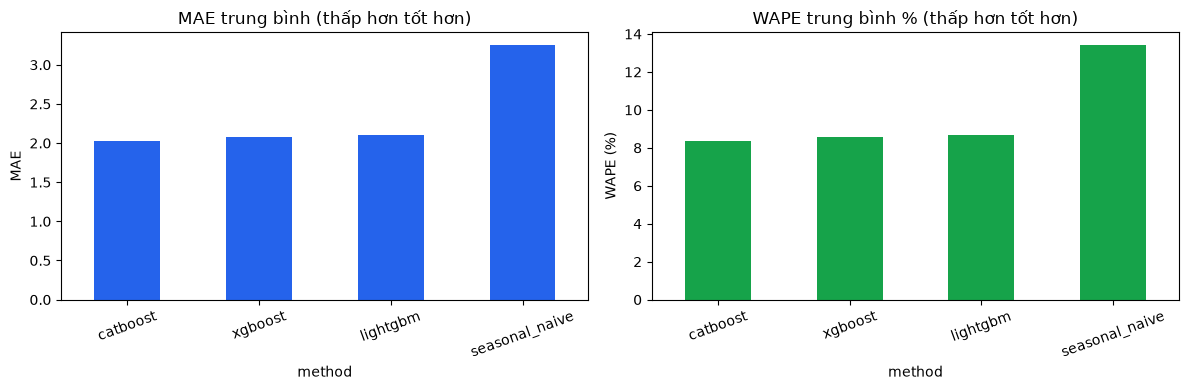

In [9]:
plot_summary = summary.set_index('method')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_summary['mae_mean'].plot(kind='bar', ax=axes[0], color='#2563eb', title='MAE trung bình (thấp hơn tốt hơn)')
plot_summary['wape_mean'].mul(100).plot(kind='bar', ax=axes[1], color='#16a34a', title='WAPE trung bình % (thấp hơn tốt hơn)')
axes[0].set_ylabel('MAE')
axes[1].set_ylabel('WAPE (%)')
for axis in axes:
    axis.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 6. Forecast 7 ngày và JSON contract cho API

Retrain model thắng trên toàn bộ lịch sử, sau đó dự báo recursive 7 ngày cho một `(store_id, sku)` được chọn.

In [10]:
REQUEST_STORE = 'STORE_01'
REQUEST_SKU = 'COCA_330'
future_start = sales['date'].max() + pd.Timedelta(days=1)
selected_metadata = sales[(sales['store_id'] == REQUEST_STORE) & (sales['sku'] == REQUEST_SKU)].iloc[0]
future_dates = pd.date_range(future_start, periods=HORIZON_DAYS, freq='D')
future_request = pd.DataFrame({
    'date': future_dates, 'store_id': REQUEST_STORE, 'sku': REQUEST_SKU,
    'category': selected_metadata['category'], 'promotion_flag': 0, 'qty': np.nan,
})
full_train_features = build_training_features(sales)
winner_model = None if winner == 'seasonal_naive' else fit_model(winner, full_train_features)
request_forecast = recursive_forecast(winner, winner_model, sales, future_request)
winner_metrics = summary.loc[summary['method'].eq(winner)].iloc[0]
api_payload = {
    'sku': REQUEST_SKU, 'store_id': REQUEST_STORE, 'horizon_days': HORIZON_DAYS,
    'method': winner, 'history_days': int(sales[(sales.store_id == REQUEST_STORE) & (sales.sku == REQUEST_SKU)].shape[0]),
    'predicted_quantity': round(float(request_forecast['predicted_qty'].sum()), 1),
    'daily_forecasts': [{'date': row.date.strftime('%Y-%m-%d'), 'predicted_quantity': round(float(row.predicted_qty), 1)} for row in request_forecast.itertuples()],
    'evaluation': {'mae_backtest': round(float(winner_metrics.mae_mean), 3), 'wape_backtest': round(float(winner_metrics.wape_mean), 4)},
    'data_source': DATA_PATH.name,
}
print(json.dumps(api_payload, ensure_ascii=False, indent=2))

{
  "sku": "COCA_330",
  "store_id": "STORE_01",
  "horizon_days": 7,
  "method": "catboost",
  "history_days": 210,
  "predicted_quantity": 238.1,
  "daily_forecasts": [
    {
      "date": "2026-09-27",
      "predicted_quantity": 38.8
    },
    {
      "date": "2026-09-28",
      "predicted_quantity": 29.1
    },
    {
      "date": "2026-09-29",
      "predicted_quantity": 29.0
    },
    {
      "date": "2026-09-30",
      "predicted_quantity": 31.0
    },
    {
      "date": "2026-10-01",
      "predicted_quantity": 33.3
    },
    {
      "date": "2026-10-02",
      "predicted_quantity": 37.7
    },
    {
      "date": "2026-10-03",
      "predicted_quantity": 39.2
    }
  ],
  "evaluation": {
    "mae_backtest": 2.029,
    "wape_backtest": 0.0837
  },
  "data_source": "sales_daily_synthetic.csv"
}


## 7. Kết luận

- Ba GBDT dùng cùng feature và cùng backtest; không chọn bằng cảm tính.
- Seasonal Naive là baseline tối thiểu.
- Khi ingestion/DB hoàn thiện, thay CSV bằng dữ liệu `GROUP BY receipt_date, store_id, product_id`, chạy lại notebook rồi lưu model thắng cho Forecast API.